In [7]:
""" Compare the cation evolution between
(1) phi = 0.2
(2) phi = 0.02
(3) phi = 0.002
(4) phi = 0 (H+ diffusion through SiO2)
"""
import os
import xarray as xr
from glob import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from utils import vert_interp
from shared_read_HBR import *
from matplotlib import rcParams
from matplotlib.patches import Patch

site = 'HBR'

rcParams['font.size'] = 16
rcParams['axes.titlesize'] = 16

elm_interface = np.array([0, 1.75, 4.51, 9.06, 16.55, 28.91, 49.29, 82.89, 138.28])
elm_nodes = (elm_interface[1:] + elm_interface[:-1]) * 0.5
elm_thickness = np.diff(elm_interface)
if site == 'HBR':
    nlevsoi = 8
else:
    nlevsoi = 10

prefix_list = ['20250720', '20250720', '20250720', '20250720', '20250720']
suffix_list = ['phi0.2', 'phi0.02', 'phi0.002', 'DSiO2']
color_list = ['#0072B2', '#E69F00', '#009E73', '#ff671e', '#FF00FF']
name_list = [r'$\Phi$=0.2', r'$\Phi$=0.02', r'$\Phi$=0.002', 'Solid', 'Solid2']

soil_pore_obs, soil_pore_obs_std = read_lysimeter()
stream, stream_std = read_streamChem()

soil_pore_obs = soil_pore_obs.loc[soil_pore_obs.index.get_level_values(1).year <= 2010]
soil_pore_obs_std = soil_pore_obs_std.loc[soil_pore_obs_std.index.get_level_values(1).year <= 2010]
stream = stream.loc[stream.index.year <= 2010]
stream_std = stream_std.loc[stream_std.index.year <= 2010]

/autofs/nccsopen-svm1_home/ywo/Git/erw_scripts/shared_read_HBR.py:58: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data',
/autofs/nccsopen-svm1_home/ywo/Git/erw_scripts/shared_read_HBR.py:58: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data',
/autofs/nccsopen-svm1_home/ywo/Git/erw_scripts/shared_read_HBR.py:109: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(os.path.join(os.environ['PROJDIR'], 'ERW_LDRD', 'data',


In [2]:
cations_collect = {}
cations_export = {}

for i, (prefix, suffix) in enumerate(zip(prefix_list, suffix_list)):
    casename = f'{prefix}_HBR_ICB20TRCNPRDCTCBC_{suffix}erw'
    flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', casename, 'run', 
                          f'{casename}.elm.h1.{yy}-01-01-00000.nc') for yy in range(1990, 2010)]

    hr = xr.open_mfdataset(flist)
    tvec = pd.DatetimeIndex([pd.Timestamp(year=t.year, month=t.month, day=t.day)
                            for t in hr['time'].to_index()])

    #-------------------------------------
    # Cation concentration in the Oe layer
    #-------------------------------------
    data = pd.DataFrame(np.nan, index = tvec, columns = ['Ca2+','Mg2+','Na+','K+','Al3+'])
    for j, (cation, mass_ca) in enumerate(zip(['Ca2+','Mg2+','Na+','K+','Al3+'], [40, 24, 23, 29, 27])):
        data.loc[:, cation] = (hr[f'cation_vr_{j+1}'][:,:2,0] / hr['H2OSOI'][:,:2,0] / mass_ca / 1000 * \
          np.array([1.75, 2.5-1.75]).reshape(1,-1)).sum(axis = 1) / 2.5
    data.loc[:, 'pH'] = (hr[f'soil_pH'][:,:2,0] * np.array([1.75, 2.5-1.75]).reshape(1,-1)).sum(axis = 1) / 2.5

    cations_collect[suffix] = data

    #-------------------------------------
    # Exported amount of cations
    #-------------------------------------
    # convert from g m-3 soil to mol/kg porewater
    rolling_window = 365 # use temporal smoothing to pretend to be runoff
    leach_sim = {}
    for i, (cation, mass_ca) in \
        enumerate(zip(['Ca2+','Mg2+','Na+','K+','Al3+','pH'], 
                      [40, 24, 23, 29, 27, 1])):

        if cation == 'pH':
            # mol/kg * kg/m2/s = mol/m2/s
            cation_leach_tot = - (10**(-hr['soil_pH'][:,:nlevsoi,0]) * \
                                  hr['QOUT_EXTERNAL'][:,:nlevsoi,0]).sum(axis = 1) + \
                              10**(-5.6) * hr['QRUNOFF'][:,0]
        else:
            # (g/m3/s * cm) / 100 = g/m2/s
            cation_leach_tot = ((hr[f'cation_leached_vr_{i+1}'][:, :, 0][:, :nlevsoi] * \
                                elm_thickness.reshape(1, -1)) / 100.).sum(axis = 1)
        # mm/s => sum up to kg/m2/s
        qout_tot = (- hr['QOUT_EXTERNAL'][:, :, 0].sum(axis = 1).values + \
                    hr['QRUNOFF'][:, 0])

        # calculate the rolling average
        cation_leach_tot = cation_leach_tot.rolling(time = rolling_window, 
                                                    min_periods = rolling_window).mean()
        qout_tot = qout_tot.rolling(time = rolling_window, 
                                    min_periods = rolling_window).mean()

        # divided by molar mass to get mol/kg
        leach_conc = (cation_leach_tot / qout_tot) / mass_ca

        if cation == 'pH':
            leach_sim['pH'] = -np.log10(leach_conc.values)
        else:
            leach_sim[cation] = leach_conc.values
    leach_sim = pd.DataFrame(leach_sim, index = tvec)

    cations_export[suffix] = leach_sim

    hr.close()

Text(0.5, 0.98, 'Simulated v.s. Observed pore water in Oe layer')

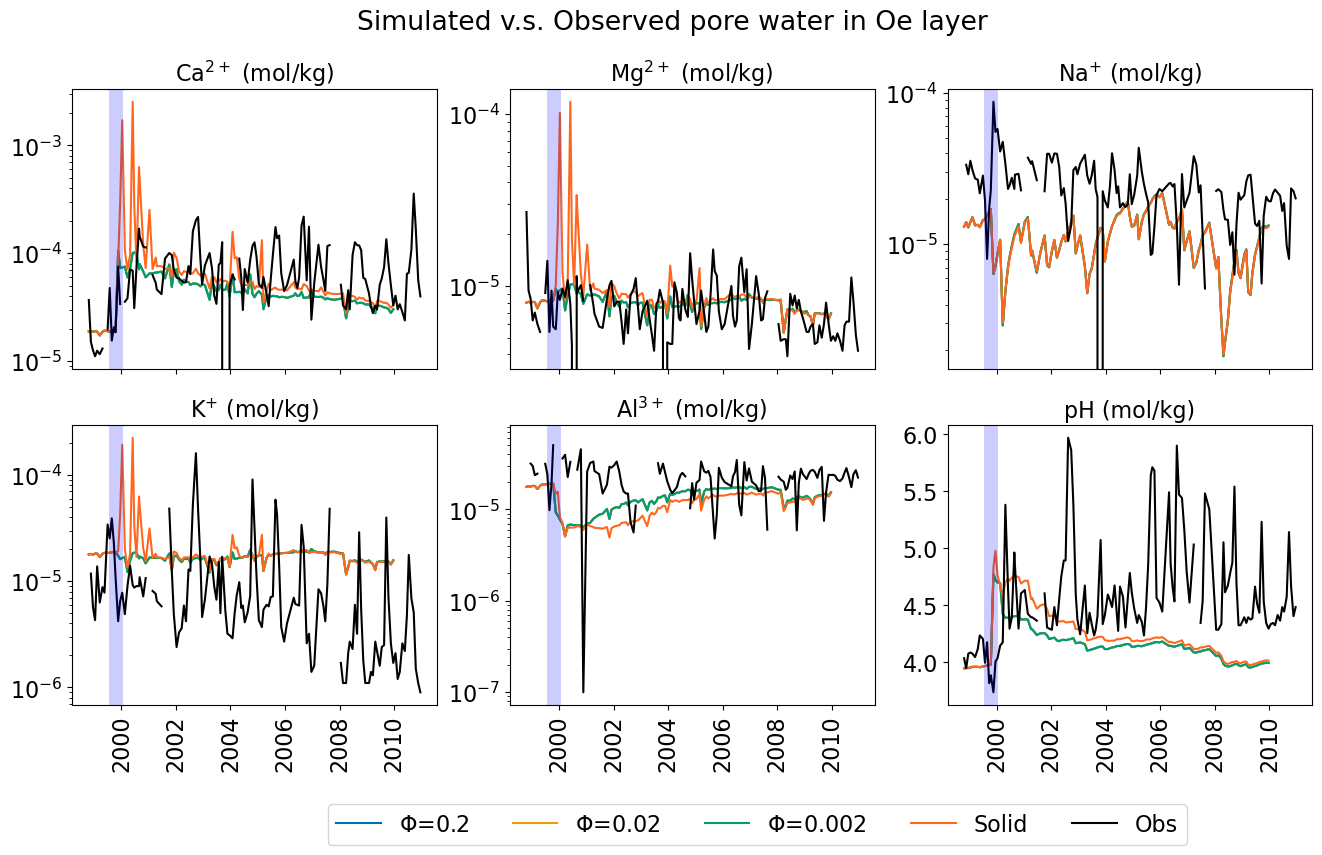

In [16]:
fig, axes = plt.subplots(2, 3, figsize = (16, 8), sharex = True)
for i, (cation, obs_ca, caname) in enumerate(zip(['Ca2+','Mg2+','Na+','K+','Al3+','pH'],
                                               ['Ca2+','Mg2+','Na+','K+','Alt','pH'],
                        ['Ca$^{2+}$', 'Mg$^{2+}$', 'Na$^{+}$', 'K$^{+}$', 'Al$^{3+}$', 'pH'])):
    ax = axes.flat[i]

    obs = soil_pore_obs.loc['Oe', obs_ca]
    obs_std = soil_pore_obs_std.loc['Oe', obs_ca]

    for prefix, suffix, color, name in zip(prefix_list, suffix_list, color_list, name_list):
        subset_sim = cations_collect[suffix][cation].loc[cations_collect[suffix].index.isin(obs.index)]
        ax.plot(subset_sim.index, subset_sim, '-', color = color, label = name)

    ax.plot(obs.index, obs, '-k', label = 'Obs')
    ax.fill_between(obs.index, obs-obs_std, obs+obs_std,
                    where = ~(np.isnan(obs) | np.isnan(obs_std)),
                    color = 'k', alpha = 0.5)

    ax.set_title(f'{caname} (mol/kg)')
    plt.setp(ax.get_xticklabels(), rotation = 90)

    ax.axvline(pd.Timestamp('1999-10-19'), ls = '-', color = 'b', lw = 10, alpha = 0.2)

    if caname != 'pH':
        ax.set_yscale('log')
ax.legend(ncol = 6, loc = (-1.7, -0.5))
plt.suptitle('Simulated v.s. Observed pore water in Oe layer')

Text(0.5, 0.98, '365-day moving average simulated runoff concentration v.s. Observed streamflow concentration')

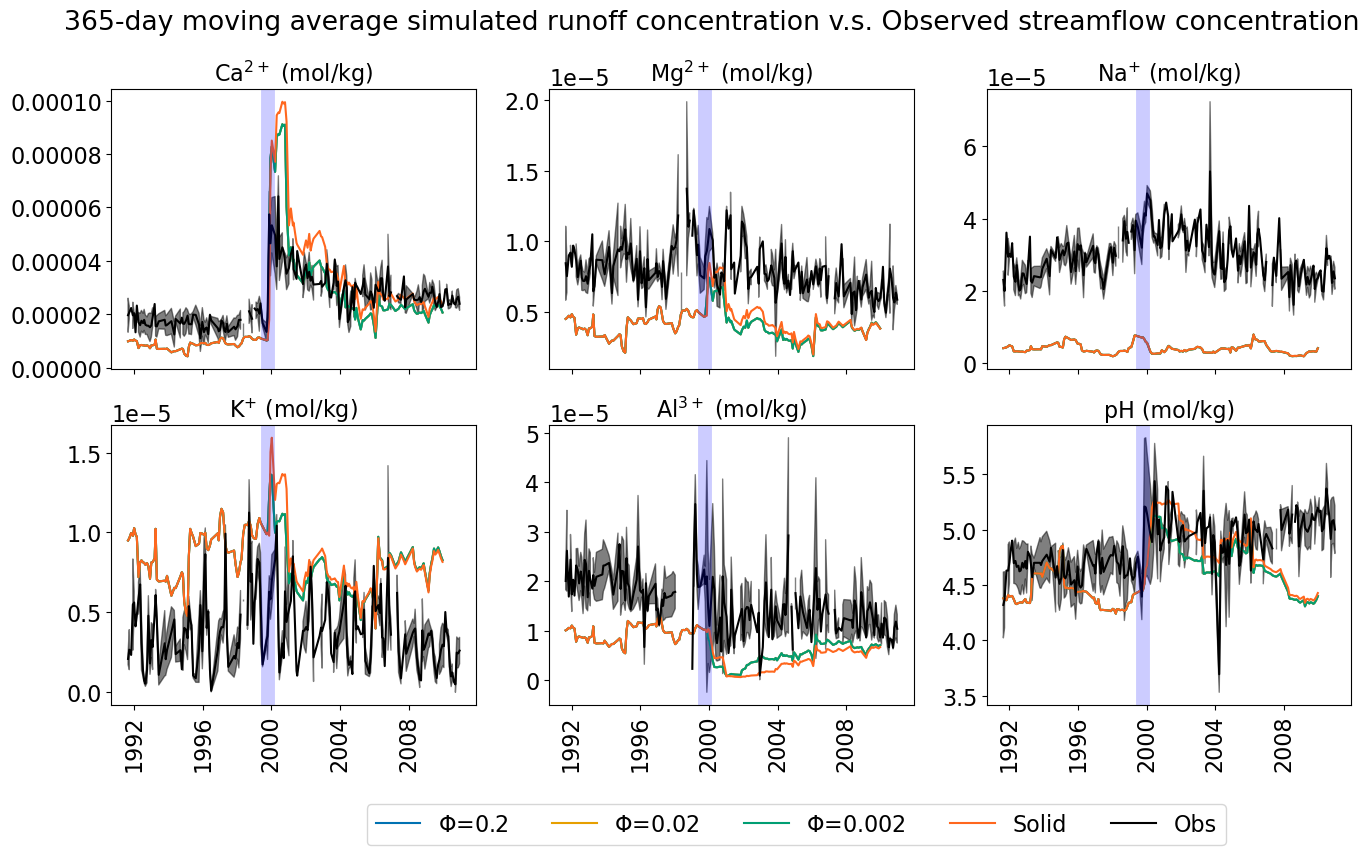

In [17]:
fig, axes = plt.subplots(2, 3, figsize = (16, 8), sharex = True)
for i, (cation, caname) in enumerate(zip(['Ca2+','Mg2+','Na+','K+','Al3+','pH'],
                        ['Ca$^{2+}$', 'Mg$^{2+}$', 'Na$^{+}$', 'K$^{+}$', 'Al$^{3+}$', 'pH'])):
    ax = axes.flat[i]

    for prefix, suffix, color, name in zip(prefix_list, suffix_list, color_list, name_list):
        subset_sim = cations_export[suffix][cation].loc[cations_export[suffix].index.isin(stream.index)]
        ax.plot(subset_sim, '-', color = color, label = name)

    ax.plot(stream[cation], '-k', label = 'Obs')
    ax.fill_between(stream.index, stream[cation]-stream_std[cation], 
                    stream[cation]+stream_std[cation], 
                    where = ~(np.isnan(stream[cation]) | np.isnan(stream_std[cation])),
                    color = 'k', alpha = 0.5)
    ax.set_title(f'{caname} (mol/kg)')
    plt.setp(ax.get_xticklabels(), rotation = 90)

    ax.axvline(pd.Timestamp('1999-10-19'), ls = '-', color = 'b', lw = 10, alpha = 0.2)

ax.legend(ncol = 6, loc = (-1.7, -0.5))
plt.suptitle('365-day moving average simulated runoff concentration v.s. Observed streamflow concentration')

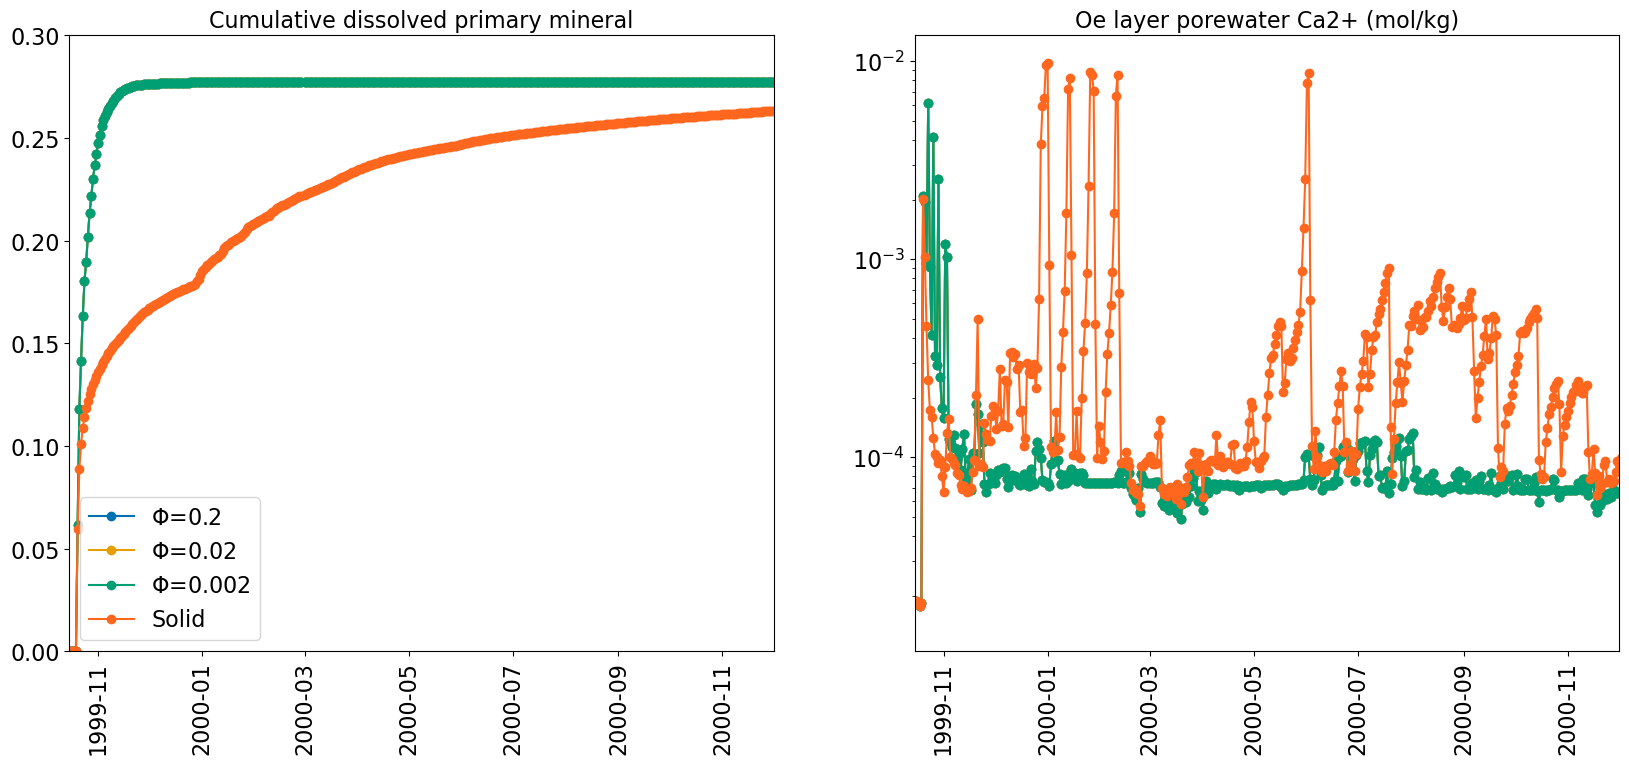

In [18]:
fig, axes = plt.subplots(1, 2, figsize = (20, 8), sharex = True)

ax = axes.flat[0]
for i, (prefix, suffix, color, name) in enumerate(zip(prefix_list, suffix_list, color_list, name_list)):
    casename = f'{prefix}_HBR_ICB20TRCNPRDCTCBC_{suffix}erw'
    flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', casename, 'run', 
                          f'{casename}.elm.h1.{yy}-01-01-00000.nc') for yy in range(1999, 2001)]

    hr = xr.open_mfdataset(flist)
    tvec = pd.DatetimeIndex([pd.Timestamp(year=t.year, month=t.month, day=t.day)
                            for t in hr['time'].to_index()])

    ax.plot(tvec, hr['primary_dissolve_vr_1'][:,0,0].cumsum(), '-o', color = color, label = name)

    hr.close()

    ax.set_xlim([pd.Timestamp('1999-10-15'), pd.Timestamp('2000-12-01')])
    plt.setp(ax.get_xticklabels(), rotation = 90)
    ax.set_ylim([0, 0.3])
    ax.legend()
    ax.set_title('Cumulative dissolved primary mineral')

ax = axes.flat[1]
for i, (prefix, suffix, color) in enumerate(zip(prefix_list, suffix_list, color_list)):
    casename = f'{prefix}_HBR_ICB20TRCNPRDCTCBC_{suffix}erw'
    flist = [os.path.join(os.environ['E3SM_ROOT'], 'output', casename, 'run', 
                          f'{casename}.elm.h1.{yy}-01-01-00000.nc') for yy in range(1999, 2001)]

    hr = xr.open_mfdataset(flist)
    tvec = pd.DatetimeIndex([pd.Timestamp(year=t.year, month=t.month, day=t.day)
                            for t in hr['time'].to_index()])

    ax.plot(tvec, 
            ((hr[f'cation_vr_1'][:,:2,0] / hr['H2OSOI'][:,:2,0] / 40. / 1000) *
             np.array([1.75, 2.5-1.75]).reshape(1,-1)).sum(axis = 1) / 2.5, '-o', color = color)

    hr.close()

    ax.set_xlim([pd.Timestamp('1999-10-15'), pd.Timestamp('2000-12-01')])
    plt.setp(ax.get_xticklabels(), rotation = 90)
    # ax.set_ylim([1e-10, 0.1])
    ax.set_yscale('log')
    ax.set_title('Oe layer porewater Ca2+ (mol/kg)')

In [6]:
""" plt.plot(tvec, hr['primary_cation_flux_vr_1'][:, 0, 0], '-o')
plt.xlim([pd.Timestamp('1999-10-15'), pd.Timestamp('2000-02-01')])
plt.setp(plt.gca().get_xticklabels(), rotation = 90)
plt.ylim([0, 0.022])


plt.plot(tvec, hr['cation_vr_1'][:, 0, 0], '-o')
plt.xlim([pd.Timestamp('1999-10-15'), pd.Timestamp('2000-02-01')])
plt.setp(plt.gca().get_xticklabels(), rotation = 90)
plt.ylim([0, 280])

plt.plot(tvec, hr['soil_pH'][:, 0, 0], '-o')
plt.plot(tvec, hr['soil_pH'][:, 1, 0], '-o')
plt.xlim([pd.Timestamp('1999-10-15'), pd.Timestamp('2000-02-01')])
plt.setp(plt.gca().get_xticklabels(), rotation = 90)
plt.ylim([3, 6])

i = 0
mass_ca = 40
plt.plot(tvec, hr[f'cation_vr_{i+1}'][:,0,0] / hr['H2OSOI'][:,0,0] / mass_ca / 1000, '-o')
plt.plot(tvec, hr[f'cation_vr_{i+1}'][:,1,0] / hr['H2OSOI'][:,1,0] / mass_ca / 1000, '-o')
plt.xlim([pd.Timestamp('1999-10-15'), pd.Timestamp('2000-02-01')])
plt.setp(plt.gca().get_xticklabels(), rotation = 90)
plt.ylim([0, 0.015]) """

" plt.plot(tvec, hr['primary_cation_flux_vr_1'][:, 0, 0], '-o')\nplt.xlim([pd.Timestamp('1999-10-15'), pd.Timestamp('2000-02-01')])\nplt.setp(plt.gca().get_xticklabels(), rotation = 90)\nplt.ylim([0, 0.022])\n\n\nplt.plot(tvec, hr['cation_vr_1'][:, 0, 0], '-o')\nplt.xlim([pd.Timestamp('1999-10-15'), pd.Timestamp('2000-02-01')])\nplt.setp(plt.gca().get_xticklabels(), rotation = 90)\nplt.ylim([0, 280])\n\nplt.plot(tvec, hr['soil_pH'][:, 0, 0], '-o')\nplt.plot(tvec, hr['soil_pH'][:, 1, 0], '-o')\nplt.xlim([pd.Timestamp('1999-10-15'), pd.Timestamp('2000-02-01')])\nplt.setp(plt.gca().get_xticklabels(), rotation = 90)\nplt.ylim([3, 6])\n\ni = 0\nmass_ca = 40\nplt.plot(tvec, hr[f'cation_vr_{i+1}'][:,0,0] / hr['H2OSOI'][:,0,0] / mass_ca / 1000, '-o')\nplt.plot(tvec, hr[f'cation_vr_{i+1}'][:,1,0] / hr['H2OSOI'][:,1,0] / mass_ca / 1000, '-o')\nplt.xlim([pd.Timestamp('1999-10-15'), pd.Timestamp('2000-02-01')])\nplt.setp(plt.gca().get_xticklabels(), rotation = 90)\nplt.ylim([0, 0.015]) "